## Setup

<font color='red'>**Warning**: if you work on Colab, upload the data zip on Google Drive in order to not have to upload it on your environment every time. It's also much faster to upload files on Google Drive than on Colab.</font>

In [19]:
#from google.colab import drive
#drive.mount('/content/drive')

In [20]:
# Make sure to change path if you put the zip elsewhere
#!unzip drive/MyDrive/chest_xray.zip
import os
if not os.path.exists('chest_xray'):
    !unzip chest_xray.zip
else:
    print("Already unzipped, skipping.")

Already unzipped, skipping.


## Create dataset from directory

In [21]:
import tensorflow as tf
from pathlib import Path

IMG_WIDTH = IMG_HEIGHT = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
  Path('chest_xray/train'),
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=64,
  class_names=['normal', 'pneumonia'],
  label_mode='binary',
  color_mode='grayscale',
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  Path('chest_xray/val'),
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=64,
  class_names=['normal', 'pneumonia'],
  label_mode='binary',
  color_mode='grayscale',
)

test_ds = tf.keras.utils.image_dataset_from_directory(
  Path('chest_xray/test'),
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=64,
  class_names=['normal', 'pneumonia'],
  label_mode='binary',
  color_mode='grayscale',
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


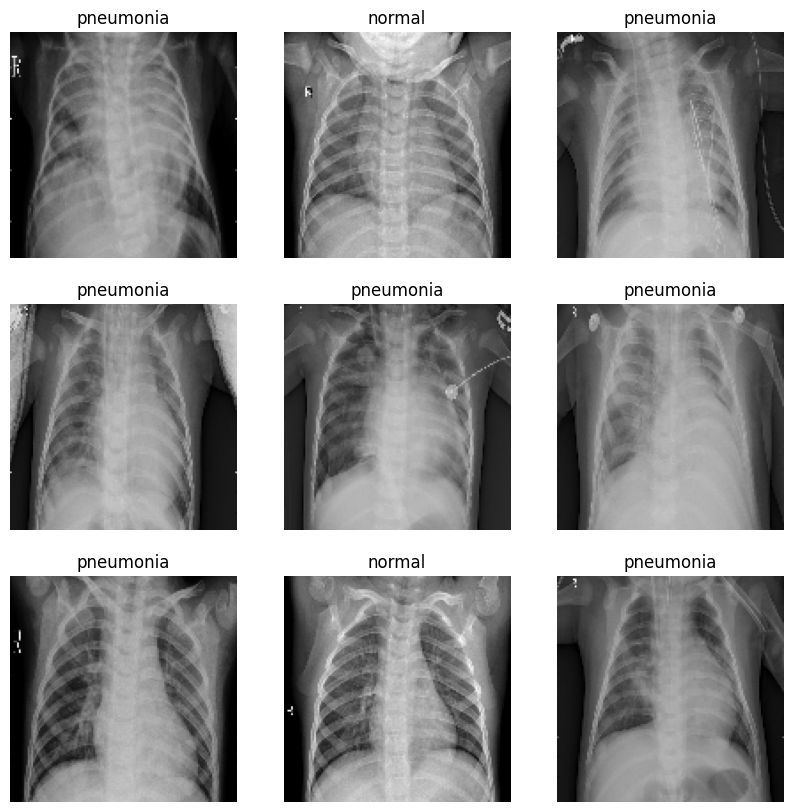

In [22]:
import matplotlib.pyplot as plt

# Extract a batch of images and labels from the training dataset
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(f'{train_ds.class_names[int(labels[i])]}')
        plt.axis('off')

    plt.show()

## Compute class weights

In [23]:
import numpy as np

# Initialize class counts
class_counts = np.zeros(len(train_ds.class_names), dtype=np.int64)

# Iterate over the dataset to count samples in each class
for images, labels in train_ds:
    flattened_labels = tf.cast(labels, dtype=tf.int64)  # Cast labels to int64
    flattened_labels = tf.reshape(flattened_labels, [-1])  # Flatten the labels
    class_counts += np.bincount(flattened_labels.numpy(), minlength=len(train_ds.class_names))

# Compute total number of samples
total_samples = np.sum(class_counts)

# Compute class weights
num_classes = len(train_ds.class_names)
class_weights = {i: total_samples / (num_classes * count) for i, count in enumerate(class_counts)}

In [24]:
class_weights

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

## Create CNN model

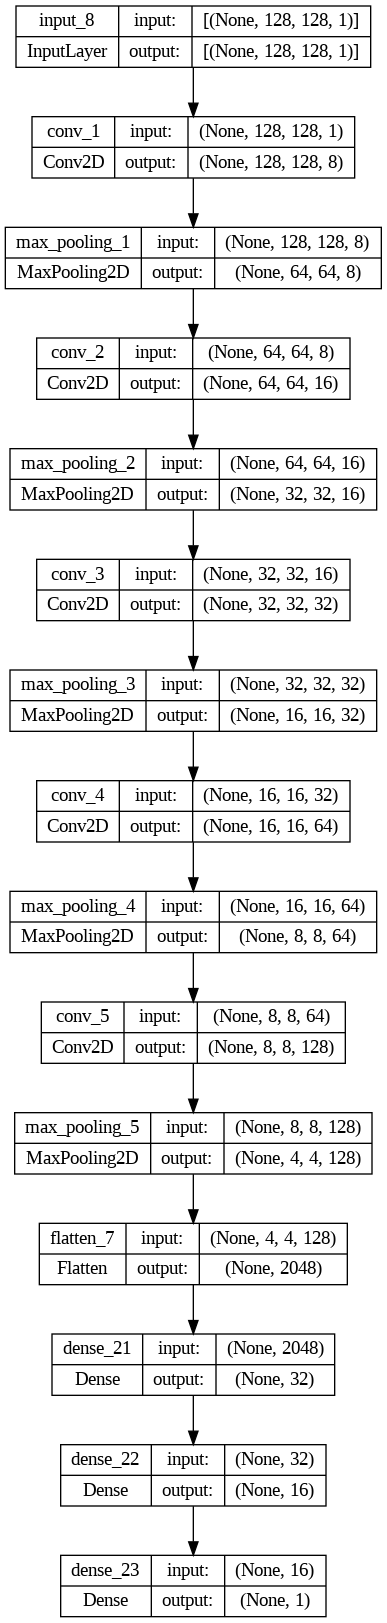

In [26]:
from tensorflow.keras import (
    layers,
    activations,
    Model,
    optimizers,
    losses
)

# Define CNN model
input = layers.Input((IMG_HEIGHT, IMG_WIDTH, 1))

# TODO: Complete this in order to have the same architecture
# as the one represented in the cell above
# note: use convolutions with relu and kernel size of 3.
l1 = layers.Conv2D(8, (3, 3), padding='same', activation='relu', name='l1')(input)
l1_mp = layers.MaxPooling2D((2, 2), name='l1_mp')(l1)

l2 = layers.Conv2D(16, (3, 3), padding='same', activation='relu', name='l2')(l1_mp)
l2_mp = layers.MaxPooling2D((2, 2), name='l2_mp')(l2)

l3 = layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='l3')(l2_mp)
l3_mp = layers.MaxPooling2D((2, 2), name='l3_mp')(l3)

l4 = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='l4')(l3_mp)
l4_mp = layers.MaxPooling2D((2, 2), name='l4_mp')(l4)

l5 = layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='l5')(l4_mp)
l5_mp = layers.MaxPooling2D((2, 2), name='l5_mp')(l5)

flat = layers.Flatten(name='flat')(l5_mp)

l6 = layers.Dense(32, activation='relu', name='l6')(flat)
l7 = layers.Dense(16, activation='relu', name='l7')(l6)

cnn_output = layers.Dense(1, activation='sigmoid')(l7)
cnn = Model(inputs=input, outputs=cnn_output)

# Compile CNN model
cnn.compile(optimizer=optimizers.Adam(0.001), loss=losses.BinaryCrossentropy(), metrics=['accuracy'])

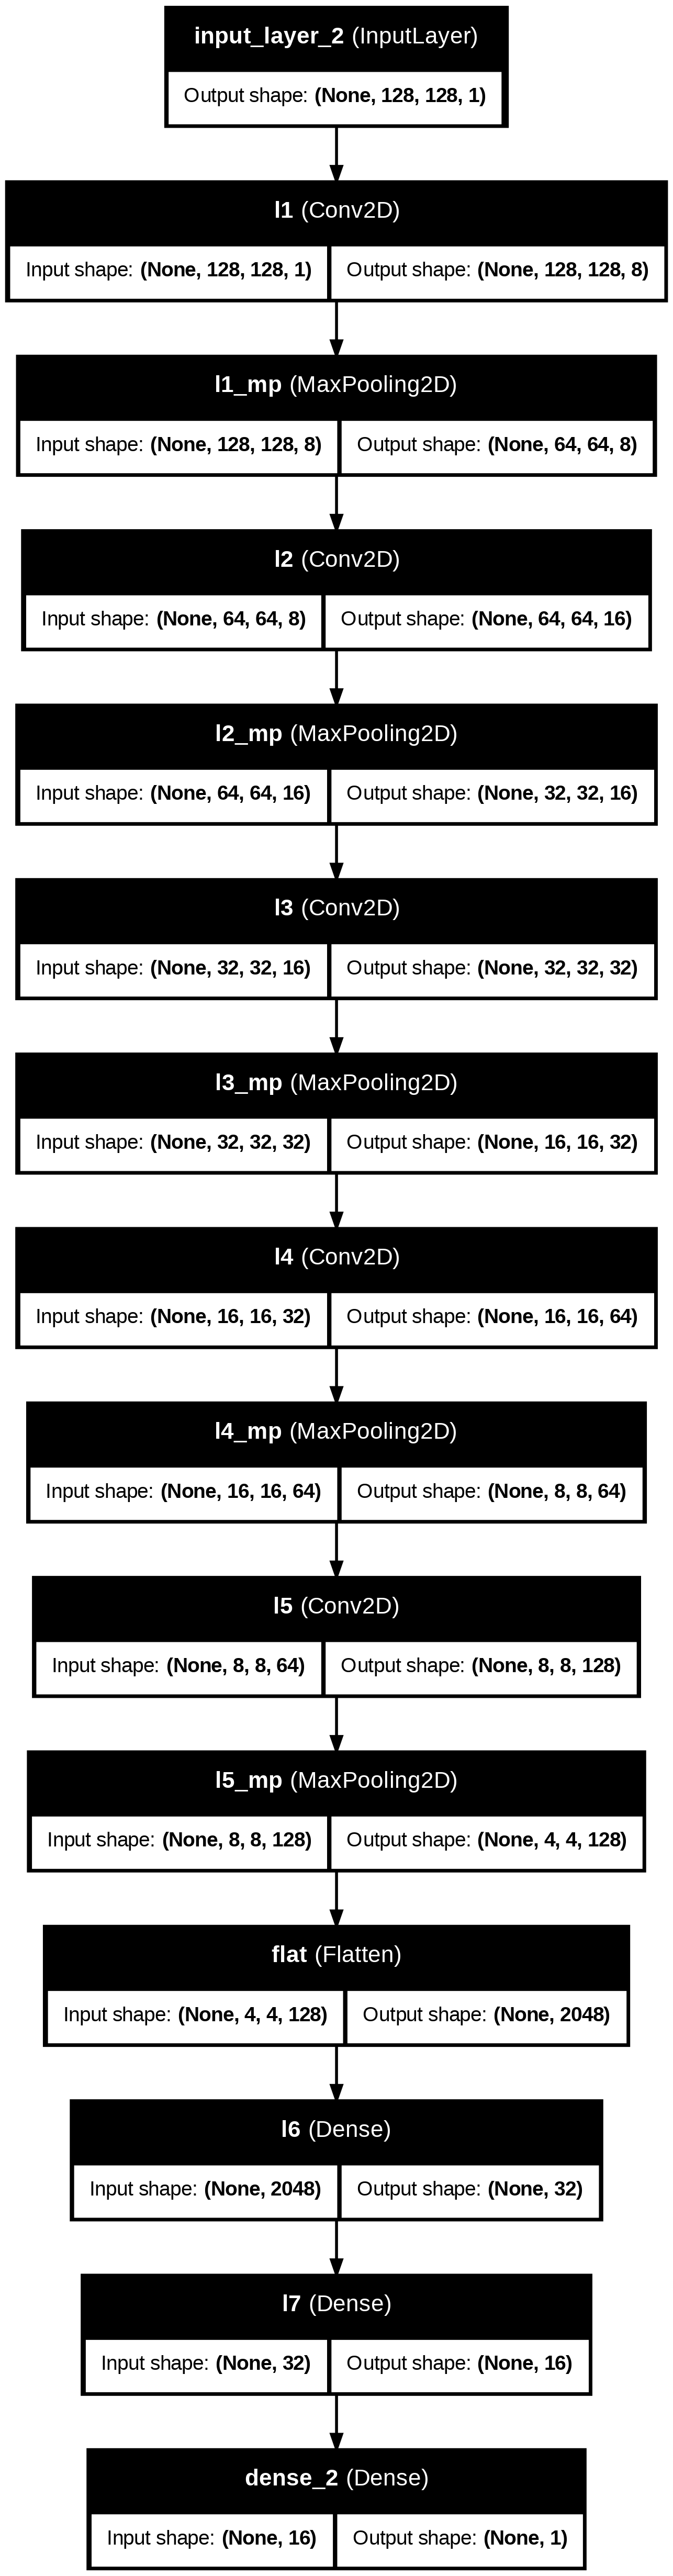

In [27]:
from tensorflow.keras.utils import plot_model

# Plot the model architecture
plot_model(cnn, show_shapes=True, show_layer_names=True)

In [28]:
history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 85s 980ms/step - accuracy: 0.7882 - loss: 0.6787 - val_accuracy: 0.7500 - val_loss: 0.4432
Epoch 2/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 83s 991ms/step - accuracy: 0.9563 - loss: 0.1098 - val_accuracy: 0.7500 - val_loss: 0.3620
Epoch 3/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 83s 996ms/step - accuracy: 0.9695 - loss: 0.0806 - val_accuracy: 0.9375 - val_loss: 0.1333
Epoch 4/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9793 - loss: 0.0548 - val_accuracy: 0.6875 - val_loss: 0.5898
Epoch 5/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9755 - loss: 0.0653 - val_accuracy: 0.8750 - val_loss: 0.2423


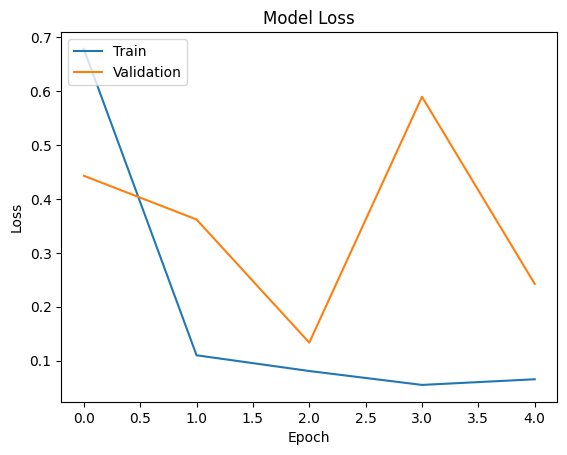

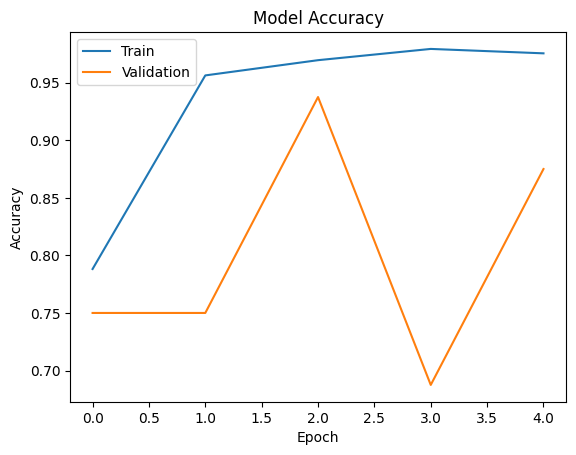

In [29]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step


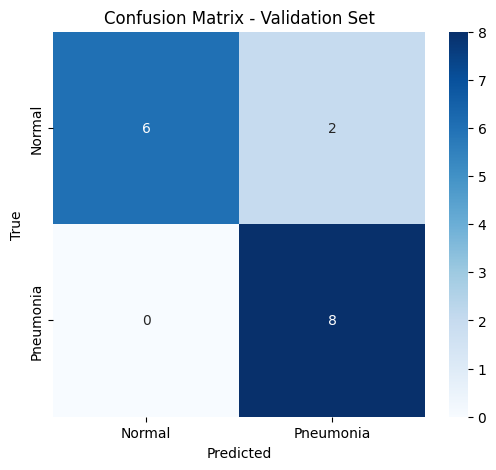

Validation Accuracy: 0.875
Validation F1 Score: 0.8888888888888888


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sns

val_images = []
val_labels = []

for img, label in val_ds:
  val_images.append(img)
  val_labels.append(label)

val_images = np.vstack(val_images)
val_labels = np.vstack(val_labels).squeeze().astype(int)

# TODO: create confusion matrix and compute metrics here
# and do the same for test set
# Create a confusion matrix
val_predictions = cnn.predict(val_images)
val_predicted_classes = np.round(val_predictions).astype(int).squeeze()

cm = confusion_matrix(val_labels, val_predicted_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Validation Set')
plt.show()

print("Validation Accuracy:", accuracy_score(val_labels, val_predicted_classes))
print("Validation F1 Score:", f1_score(val_labels, val_predicted_classes))


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step


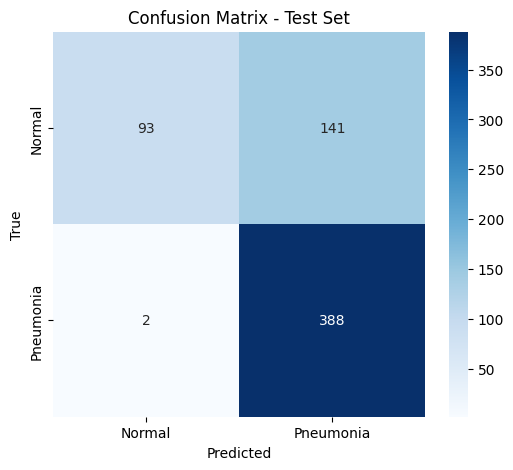

Test Accuracy: 0.7708333333333334
Test F1 Score: 0.8443960826985855


In [33]:
test_images = []
test_labels = []

for img, label in test_ds:
    test_images.append(img)
    test_labels.append(label)

test_images = np.vstack(test_images)
test_labels = np.vstack(test_labels).squeeze().astype(int)

test_predictions = cnn.predict(test_images)
test_predicted_classes = np.round(test_predictions).astype(int).squeeze()

test_cm = confusion_matrix(test_labels, test_predicted_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.show()

print("Test Accuracy:", accuracy_score(test_labels, test_predicted_classes))
print("Test F1 Score:", f1_score(test_labels, test_predicted_classes))